<center><h1><strong>Анализ датасета</strong></h1><center>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("hirehi_parsing.csv")
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,от 240 000 ₽,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,от 350 000 ₽,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,~ 372 000 ₽,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,~ 223 000 ₽,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,~ 210 000 ₽,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,от 180 до 220 ₽,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,от 150 000 ₽,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,от 200 000 до 285 000 ₽,https://hirehi.ru/analytics/sistemnyi-analitik...


In [3]:
df.isna().sum()

id           0
title        0
category     0
company      0
format       0
level        0
salary      46
link         0
dtype: int64

<center><strong>Заметим, что пропуски у нас есть только в столбце "salary"</br>
Попозже разберемся как их заполнить</strong></center>


In [4]:
df.duplicated().sum()

np.int64(0)

<center><strong>дубликатов нет, хорошо</strong></center>

In [5]:
df["category"].value_counts()

category
development    3612
analytics      1325
management     1116
qa              914
design          753
devops          596
marketing       438
Name: count, dtype: int64

Видим 7 категорий в "category"

<center><h2><strong>1) Займемся обработкой "salary"</strong></h2></center> </br>Знаем, что есть 46 пропусков, на первый взгляд видим, что есть данные в таких форматах 'от 350 000 ₽', '~ 223 000 ₽', 'от 220 000 до 268 000 ₽', 'от 180 до 220 ₽'. Для начала оставим только цифры, а также посмотрим, есть ли в наших данных зарплаты в долларах.</strong></h4> 

In [6]:
df["salary"].unique().tolist()

['от 240 000 ₽',
 'от 350 000 ₽',
 '~ 372 000 ₽',
 '~ 223 000 ₽',
 '~ 210 000 ₽',
 '~ 345 000 ₽',
 'от 90 000 ₽',
 'от 320 000 ₽',
 '~ 65 000 ₽',
 '~ 282 000 ₽',
 '~ 386 000 ₽',
 '80 000 ₽',
 'зп не указана',
 '~ 371 000 ₽',
 '~ 318 000 ₽',
 'от 180 000 ₽',
 '~ 204 000 ₽',
 '~ 220 000 ₽',
 'от 160 000 ₽',
 '40 000 ₽',
 '~ 215 000 ₽',
 '~ 395 000 ₽',
 '~ 320 000 ₽',
 '~ 411 000 ₽',
 '~ 409 000 ₽',
 '~ 227 000 ₽',
 '240 000 ₽',
 '~ 68 000 ₽',
 '~ 325 000 ₽',
 '~ 265 000 ₽',
 'от 192 000 ₽',
 '~ 393 000 ₽',
 '~ 226 000 ₽',
 '~ 381 000 ₽',
 '~ 387 000 ₽',
 '~ 172 000 ₽',
 '~ 82 000 ₽',
 '~ 410 000 ₽',
 '~ 168 000 ₽',
 '~ 231 000 ₽',
 '~ 200 000 ₽',
 '~ 110 000 ₽',
 '~ 211 000 ₽',
 '~ 294 000 ₽',
 'от 150 000 ₽',
 '~ 80 000 ₽',
 '~ 91 000 ₽',
 'от 20 000 ₽',
 'от 250 000 ₽',
 '~ 347 000 ₽',
 '250 000 ₽',
 'от 65 000 ₽',
 'от 300 000 ₽',
 '~ 251 000 ₽',
 '~ 328 000 ₽',
 '~ 66 000 ₽',
 '~ 189 000 ₽',
 '~ 258 000 ₽',
 '~ 183 000 ₽',
 '~ 67 000 ₽',
 '~ 240 000 ₽',
 '~ 72 000 ₽',
 '~ 62 000 ₽',


Посмотрим есть ли у нас доллары(их нет), почти все строки в рублях

In [7]:
dollarorruble = df["salary"].str.contains(r"\$|₽").sum()
dollarorruble

np.int64(8488)

Знаем, что у нас 8754 строки, 8488 строк с рублями, тогда что в оставшихся 266 строках? 

In [8]:
not_dollarorruble = df["salary"].str.contains(r"\$|₽") == False

Посмотрим что в тех строках, где не доллар и не рубль

In [9]:
df[not_dollarorruble]["salary"].unique()

<StringArray>
['зп не указана', nan, 'зп не указана ', 'не оплачивается']
Length: 4, dtype: str

Видим, что оставшиеся ячейки это либо пропуски, либо зарплата не указана явно, можно приравнять эти строки к пропускам, чтобы потом заполнить их по общему правилу. 

In [10]:
df["salary"] = df["salary"].replace(
    ["зп не указана", "зп не указана ", "не оплачивается"], np.nan
)
df["salary"].isna().sum()

np.int64(266)

теперь получили 266 пропусков в столбце salary, вернемся к ним позже, пока займемся приведением зарплат к числам. </br> Нужно как-то склеить тысячи, чтобы при последующей замене на пробелы всего, кроме цифр, вилки не склеились в одно целое. 

In [11]:
df["salary"] = df["salary"].str.replace(r"[^\d]", " ", regex=True).str.strip()

Удалили все, кроме цифр

In [12]:
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240 000,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350 000,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372 000,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223 000,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210 000,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180 220,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150 000,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200 000 285 000,https://hirehi.ru/analytics/sistemnyi-analitik...


там, где мы заменили буквы, осталось несколько пробелов, пожэтому заменим их на один, а единственный между тысячами("000") в вилках уберем. Но чтобы нужные пробелы не удалились, заменим их на временные разделители, которые потом тоже удалим.</br>Чтобы понять, как обнаруживать два и более пробелов подряд, использовал эту <a href = "https://habr.com/ru/articles/349860/">статью</a>

In [13]:
df["salary"] = df["salary"].str.replace(r"\s{2,}", "*", regex=True)
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240 000,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350 000,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372 000,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223 000,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210 000,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180*220,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150 000,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200 000*285 000,https://hirehi.ru/analytics/sistemnyi-analitik...


заменим двойные и больше пробелы на "*", чтобы не склеилось все, дальше удалим одиночные пробелы. 

In [14]:
df["salary"] = df["salary"].str.replace(r"\s", "", regex=True)
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180*220,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200000*285000,https://hirehi.ru/analytics/sistemnyi-analitik...


Удаляем звездочку и заменяем ее на пробел

In [15]:
df["salary"] = df["salary"].str.replace("*", " ")
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180 220,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200000 285000,https://hirehi.ru/analytics/sistemnyi-analitik...


На всякий случай еще раз обрежем края

In [16]:
df["salary"] = df["salary"].str.strip()
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180 220,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200000 285000,https://hirehi.ru/analytics/sistemnyi-analitik...


Видим, что остались вилки, вместо них подставим среднее значение. Также умножим на 1000 те результаты, которые окажутся меньше 1000

In [17]:
def count_avg(i):
    fork = str(i).split()
    values = []
    for j in fork:
        values.append(float(j))
    if len(values) == 2:
        salary = (values[0] + values[1]) / 2
    elif len(values) == 1:
        salary = values[0]
    else:
        return np.nan

    if salary <= 1000:
        salary = salary * 1000

    return salary

Применим функцию к столбцу salary

In [18]:
df["salary"] = df["salary"].apply(count_avg)
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000.0,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000.0,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372000.0,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000.0,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000.0,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,200000.0,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000.0,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,242500.0,https://hirehi.ru/analytics/sistemnyi-analitik...


<h3><strong>Теперь заполним пропуски, для этого будем смотреть category и level и будем рассчитывать число для пропуска исходя из зарплат в этой категории и этого уровня.</strong></h3>

In [19]:
df["level"].value_counts()

level
middle        4235
senior        3089
lead           768
junior         468
intern         129
head            63
грейда нет       1
не указан        1
Name: count, dtype: int64

Так мы нашли что есть несколько грейдов:</br>
1) intern</br>
2) junior</br>
3) middle</br>
5) senior</br> 
5) lead</br>
5) head</br>

In [20]:
head = df["level"].str.contains("head")
df_head = df[head]
df_head

,id,title,category,company,format,level,salary,link
720,35969,Tech lead,development,Аддамант,удалённо,head,360000.0,https://hirehi.ru/development/tech-lead-35969
760,35926,head of marketing,marketing,NDA,удалённо,head,200000.0,https://hirehi.ru/marketing/head-of-marketing-...
979,35694,product designer,design,1inch,офис Дубай,head,595000.0,https://hirehi.ru/design/product-designer-35694
1368,35280,директор по маркетингу,marketing,NDA,офис,head,376000.0,https://hirehi.ru/marketing/direktor-po-market...
1463,35180,cpo,management,Плати по миру,офис Москва,head,500000.0,https://hirehi.ru/management/cpo-35180
...,...,...,...,...,...,...,...,...
7836,26835,cpo,management,Сбер,офис Москва,head,584300.0,https://hirehi.ru/management/cpo-26835
8037,26544,cto,development,NDA,удалённо,head,791400.0,https://hirehi.ru/development/cto-26544
8109,26425,product analyst,analytics,Sweed,удалённо,head,494600.0,https://hirehi.ru/analytics/product-analyst-26425
8674,25577,backend разработчик,development,Т-Банк,гибрид Москва,head,715300.0,https://hirehi.ru/development/backend-razrabot...


In [21]:
nograde = df["level"].str.contains("грейда нет")
df_nograde = df[nograde]
df_nograde

,id,title,category,company,format,level,salary,link
2147,34417,AI Frontend Design Engineer,design,EGO digital,удалённо,грейда нет,240000.0,https://hirehi.ru/design/ai-frontend-design-en...


In [22]:
none = df["level"].str.contains("не указан")
df_none = df[none]
df_none

,id,title,category,company,format,level,salary,link
6452,28919,разработчик 1c,development,topgo.group,гибрид Питер,не указан,150000.0,https://hirehi.ru/development/razrabotchik-1c-...


Нужно присвоить грейд двум вакансиям без грейда, для этого посмотрим на медианные значения зарплат в их категории. 

In [23]:
df["category"].value_counts()

category
development    3612
analytics      1325
management     1116
qa              914
design          753
devops          596
marketing       438
Name: count, dtype: int64

In [24]:
categories = df.groupby(["category", "level"])["salary"].agg(["median"])
categories

median
category    level               
analytics   head        462000.0
            intern       65000.0
            junior      101650.0
            lead        360500.0
            middle      208200.0
            senior      282400.0
design      head        518900.0
            intern       50700.0
            junior       70000.0
            lead        314800.0
            middle      139000.0
            senior      274550.0
            грейда нет  240000.0
development head        606150.0
            intern       60000.0
            junior       80000.0
            lead        412200.0
            middle      224750.0
            senior      336000.0
            не указан   150000.0
devops      intern       53400.0
            junior       97000.0
            lead        411400.0
            middle      231150.0
            senior      343400.0
management  head        496850.0
            intern       67250.0
            junior       98300.0
            lead        388500.0
            middle      224450.0
            senior      339000.0
marketing   head        457100.0
            intern       58900.0
            junior       62350.0
            lead        328000.0
            middle      154900.0
            senior      256300.0
qa          head        519900.0
            intern       50700.0
            junior       81000.0
            lead        342200.0
            middle      194300.0
            senior      277750.0

In [25]:
withnonegrade = categories.loc[["design", "development"]]
withnonegrade

median
category    level               
design      head        518900.0
            intern       50700.0
            junior       70000.0
            lead        314800.0
            middle      139000.0
            senior      274550.0
            грейда нет  240000.0
development head        606150.0
            intern       60000.0
            junior       80000.0
            lead        412200.0
            middle      224750.0
            senior      336000.0
            не указан   150000.0

Видим, что вакансия в дизайне ближе к senior, а в разработке - к middle

In [26]:
df.loc[(df["category"] == "design") & (df["level"] == "грейда нет"), "level"] = "senior"
df.loc[(df["category"] == "development") & (df["level"] == "не указан"), "level"] = (
    "middle"
)

In [27]:
df["level"].value_counts()

level
middle    4236
senior    3090
lead       768
junior     468
intern     129
head        63
Name: count, dtype: int64

Теперь у нас 6 категорий грейдов, теперь можем заполнить медианными значениями пропуски по зарплате, воспользуемся функцией <a href = "https://dfedorov.spb.ru/pandas/Понимание%20функции%20transform%20в%20Pandas.html">transform</a>  

In [28]:
df["salary"] = df["salary"].fillna(
    df.groupby(["category", "level"])["salary"].transform("median")
)
df.isna().sum()

id          0
title       0
category    0
company     0
format      0
level       0
salary      0
link        0
dtype: int64

In [29]:
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000.0,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000.0,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372000.0,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000.0,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000.0,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,200000.0,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000.0,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,98300.0,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,242500.0,https://hirehi.ru/analytics/sistemnyi-analitik...


In [30]:
df["salary"] = df["salary"].astype(int)
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,200000,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,98300,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...


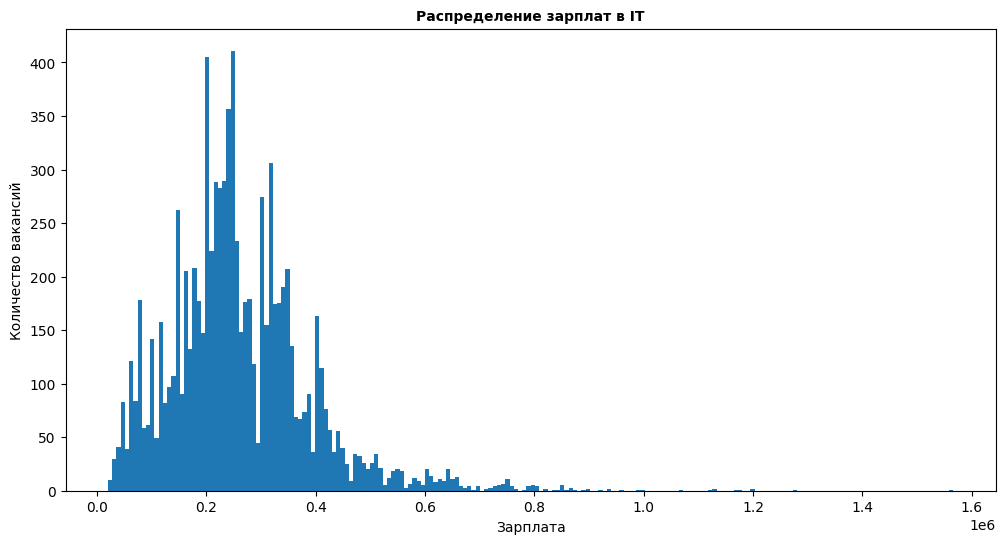

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(df["salary"], bins=200)
plt.title("Распределение зарплат в IT", fontsize=10, fontweight="bold")
plt.xlabel("Зарплата")
plt.ylabel("Количество вакансий")
plt.show()

In [32]:
df["salary"].dropna().sort_values().tail(20)

7985     876700
4975     893400
1362     900000
524      900000
2913     919700
5879     933333
8648     936500
6554     963333
8443     993333
7965    1000000
6570    1066666
6052    1120000
6002    1133333
6690    1133333
8629    1170400
6067    1178500
6735    1200000
732     1200000
6037    1280000
1868    1566666
Name: salary, dtype: int64

In [33]:
df[df["salary"] > 850000]

,id,title,category,company,format,level,salary,link
524,36167,full stack developer,development,Apollo,офис Лондон,senior,900000,https://hirehi.ru/development/full-stack-devel...
732,35956,performance marketing manager,marketing,Plurio,удалённо,senior,1200000,https://hirehi.ru/marketing/performance-market...
909,35769,product manager,management,FMG,удалённо,senior,866666,https://hirehi.ru/management/product-manager-3...
1362,35287,python developer,development,Neru Health,гибрид Мюнхен,senior,900000,https://hirehi.ru/development/python-developer...
1739,34884,product lead,management,WeLoveNoCode,офис Сан-Франциско,lead,850500,https://hirehi.ru/management/product-lead-34884
1868,34748,project manager,management,Nebius,удалённо,senior,1566666,https://hirehi.ru/management/project-manager-3...
2913,33557,site reliability engineer,devops,Clever Recruiting,удалённо,lead,919700,https://hirehi.ru/devops/site-reliability-engi...
4091,32165,ml engineer,development,Recraft,офис Лондон,senior,866000,https://hirehi.ru/development/ml-engineer-32165
4975,31066,rust backend разработчик,development,Douro Labs,удалённо,senior,893400,https://hirehi.ru/development/rust-backend-raz...
5141,30856,cto,development,Muse Group,удалённо,lead,850500,https://hirehi.ru/development/cto-30856


<center><b><h3>Закончили с level и salary</h3></b></center>

<center><h2><strong>2) Дальше разберемся с "format"</strong></h2></center>

In [34]:
df["format"].unique().tolist()

['удалённо по РФ',
 'удалённо',
 'гибрид Москва',
 'гибрид Н.Новгород',
 'офис',
 'офис Москва',
 'офис Астана',
 'гибрид Питер',
 'офис Минск',
 'гибрид',
 'офис Питер',
 'офис Ростов',
 'гибрид Краснодар',
 'гибрид Воронеж',
 'офис Белград',
 'офис Ташкент',
 'офис Лимассол',
 'гибрид Астана',
 'гибрид Минск',
 'офис Алматы',
 'офис Лимасол',
 'офис Казань',
 'офис Екатеринбург',
 'офис Пенза',
 'гибрид Алматы',
 'гибрид Лимассол',
 'офис Великие Луки',
 'гибрид Барселона',
 'офис Самара',
 'гибрид Екатеринбург',
 'офис Сочи',
 'офис Лондон',
 'гибрид Самара',
 'офис Ярославль',
 'офис Ереван',
 'гибрид Белград',
 'гибрид Новосибирск',
 'офис Красноярск',
 'офис Бишкек',
 'офис Берлин',
 'офис Новороссийск',
 'офис Абу-Даби',
 'офис Манила',
 'офис Дубай',
 'гибрид Варшава',
 'офис Тбилиси',
 'офис Н.Новгород',
 'офис Куала-Лумпур',
 'гибрид Томск',
 'офис Томск',
 'гибрид Сербия',
 'гибрид Мюнхен',
 'офис Псков',
 'офис Пермь',
 'офис Рига',
 'офис Новосибирск',
 'офис Гродно',
 'ги

просмотрев какие у нас есть форматы, заметим, что есть формата <i>Гибрид - город</i>, <i>Офис - город</i>, <i>удалённо по РФ</i>, <i>удалённо</i>, <i>гибрид</i>,<i>офис</i>

In [35]:
df["format"] = df["format"].str.replace("удалённо по РФ", "удалённо РФ")
df["format"] = df["format"].str.replace("Казан", "Казань")

Исправили то, что первым попалось на глаза. 

In [36]:
df["format"].unique().tolist()

['удалённо РФ',
 'удалённо',
 'гибрид Москва',
 'гибрид Н.Новгород',
 'офис',
 'офис Москва',
 'офис Астана',
 'гибрид Питер',
 'офис Минск',
 'гибрид',
 'офис Питер',
 'офис Ростов',
 'гибрид Краснодар',
 'гибрид Воронеж',
 'офис Белград',
 'офис Ташкент',
 'офис Лимассол',
 'гибрид Астана',
 'гибрид Минск',
 'офис Алматы',
 'офис Лимасол',
 'офис Казаньь',
 'офис Екатеринбург',
 'офис Пенза',
 'гибрид Алматы',
 'гибрид Лимассол',
 'офис Великие Луки',
 'гибрид Барселона',
 'офис Самара',
 'гибрид Екатеринбург',
 'офис Сочи',
 'офис Лондон',
 'гибрид Самара',
 'офис Ярославль',
 'офис Ереван',
 'гибрид Белград',
 'гибрид Новосибирск',
 'офис Красноярск',
 'офис Бишкек',
 'офис Берлин',
 'офис Новороссийск',
 'офис Абу-Даби',
 'офис Манила',
 'офис Дубай',
 'гибрид Варшава',
 'офис Тбилиси',
 'офис Н.Новгород',
 'офис Куала-Лумпур',
 'гибрид Томск',
 'офис Томск',
 'гибрид Сербия',
 'гибрид Мюнхен',
 'офис Псков',
 'офис Пермь',
 'офис Рига',
 'офис Новосибирск',
 'офис Гродно',
 'гибр

Занасем в списки, чтоб потом легко разбросить по 2 столбцам формат и город/страну. 

In [37]:
df["format"] = df["format"].str.split()
df

,id,title,category,company,format,level,salary,link
0,36700,quality assurance (manual),qa,NDA,"[удалённо, РФ]",senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...
1,36699,iOS разработчик,development,Экосистема тенниса,[удалённо],senior,350000,https://hirehi.ru/development/ios-razrabotchik...
2,36697,platform engineer,devops,NDA,[удалённо],senior,372000,https://hirehi.ru/devops/platform-engineer-36697
3,36696,growth marketing manager,marketing,NDA,[удалённо],middle,223000,https://hirehi.ru/marketing/growth-marketing-m...
4,36695,Бизнес аналитик,analytics,ВТБ,"[гибрид, Москва]",middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695
...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,[удалённо],middle,200000,https://hirehi.ru/development/ml-engineer-24856
8750,24838,Разработчик PHP,development,Системы документооборота,"[офис, Казаньь]",senior,150000,https://hirehi.ru/development/razrabotchik-php...
8751,24836,Проектный менеджер IT,management,Системы документооборота,"[офис, Казань]",junior,98300,https://hirehi.ru/management/proektnyi-menedzh...
8752,24787,Системный Аналитик,analytics,iStaff-IT,"[удалённо, РФ]",senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...


In [38]:
df["format1"] = df["format"].str[0]
df["city/country"] = df["format"].str[1]
df

,id,title,category,company,format,level,salary,link,format1,city/country
0,36700,quality assurance (manual),qa,NDA,"[удалённо, РФ]",senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,[удалённо],senior,350000,https://hirehi.ru/development/ios-razrabotchik...,удалённо,NaN
2,36697,platform engineer,devops,NDA,[удалённо],senior,372000,https://hirehi.ru/devops/platform-engineer-36697,удалённо,NaN
3,36696,growth marketing manager,marketing,NDA,[удалённо],middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,удалённо,NaN
4,36695,Бизнес аналитик,analytics,ВТБ,"[гибрид, Москва]",middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,гибрид,Москва
...,...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,[удалённо],middle,200000,https://hirehi.ru/development/ml-engineer-24856,удалённо,NaN
8750,24838,Разработчик PHP,development,Системы документооборота,"[офис, Казаньь]",senior,150000,https://hirehi.ru/development/razrabotchik-php...,офис,Казаньь
8751,24836,Проектный менеджер IT,management,Системы документооборота,"[офис, Казань]",junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,"[удалённо, РФ]",senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,удалённо,РФ


In [39]:
df["format1"].unique()

array(['удалённо', 'гибрид', 'офис'], dtype=object)

с колонкой format1 все в порядке, теперь посмотрим на города и страны

In [40]:
df["city/country"].unique()

array(['РФ', nan, 'Москва', 'Н.Новгород', 'Астана', 'Питер', 'Минск',
       'Ростов', 'Краснодар', 'Воронеж', 'Белград', 'Ташкент', 'Лимассол',
       'Алматы', 'Лимасол', 'Казаньь', 'Екатеринбург', 'Пенза', 'Великие',
       'Барселона', 'Самара', 'Сочи', 'Лондон', 'Ярославль', 'Ереван',
       'Новосибирск', 'Красноярск', 'Бишкек', 'Берлин', 'Новороссийск',
       'Абу-Даби', 'Манила', 'Дубай', 'Варшава', 'Тбилиси',
       'Куала-Лумпур', 'Томск', 'Сербия', 'Мюнхен', 'Псков', 'Пермь',
       'Рига', 'Гродно', 'Киров', 'Тюмень', 'Сан-Франциско', 'Тула',
       'Пафос', 'Караганда', 'Вологда', 'Кипр', 'Тель-Авив',
       'Калининград', 'Рязань', 'Лиссабон', 'Владивосток', 'Киев',
       'Иннополис', 'Париж', 'Хабаровск', 'Санкт-Петербург', 'Никосия',
       'Прага', 'Валенсия', 'Чехов', 'Мадрид', 'Покров', 'Благовещенск',
       'Краков', 'Елабуга', 'Тольятти', 'Барнаул', 'Саратов',
       '(офис/удалёнка)', 'Вроцлав', 'Тверь', 'Ставрополь', 'Гданьск',
       'Баку', 'Польша', 'Гамбур

In [41]:
unitedcities = {
    "Н.Новгород": "Нижний Новгород",
    "Питер": "Санкт-Петербург",
    "Лимасол": "Лимассол",
    "Казаньь": "Казань",
    "Kraków": "Краков",
    "Моск.обл": "Москва",
    "(офис/удалёнка)": np.nan,
    "<город>": np.nan,
    "Сколково": "Москва",
    "Зеленоград": "Москва",
    "Химки": "Москва",
    "Одинцово": "Москва",
    "Фрязино": "Москва",
    "Москва/Питер": "Москва",
    "Алматы/Ташкент": "Алматы",
    "Астана/Алматы": "Астана",
    "Минск/Варшава": "Минск",
}
df["city/country"] = df["city/country"].replace(unitedcities)

После замены на пропуски невалидных названий и правки одинаковых по сути названий получим готовый список локаций вакансий.  

In [42]:
df["city/country"].unique()

array(['РФ', nan, 'Москва', 'Нижний Новгород', 'Астана',
       'Санкт-Петербург', 'Минск', 'Ростов', 'Краснодар', 'Воронеж',
       'Белград', 'Ташкент', 'Лимассол', 'Алматы', 'Казань',
       'Екатеринбург', 'Пенза', 'Великие', 'Барселона', 'Самара', 'Сочи',
       'Лондон', 'Ярославль', 'Ереван', 'Новосибирск', 'Красноярск',
       'Бишкек', 'Берлин', 'Новороссийск', 'Абу-Даби', 'Манила', 'Дубай',
       'Варшава', 'Тбилиси', 'Куала-Лумпур', 'Томск', 'Сербия', 'Мюнхен',
       'Псков', 'Пермь', 'Рига', 'Гродно', 'Киров', 'Тюмень',
       'Сан-Франциско', 'Тула', 'Пафос', 'Караганда', 'Вологда', 'Кипр',
       'Тель-Авив', 'Калининград', 'Рязань', 'Лиссабон', 'Владивосток',
       'Киев', 'Иннополис', 'Париж', 'Хабаровск', 'Никосия', 'Прага',
       'Валенсия', 'Чехов', 'Мадрид', 'Покров', 'Благовещенск', 'Краков',
       'Елабуга', 'Тольятти', 'Барнаул', 'Саратов', 'Вроцлав', 'Тверь',
       'Ставрополь', 'Гданьск', 'Баку', 'Польша', 'Гамбург', 'Темиртау',
       'Доха', 'Мальта', '

In [43]:
df["city/country"].isna().sum()

np.int64(4812)

In [44]:
print(df[df["city/country"].isna()]["format1"].value_counts())

format1
удалённо    4571
гибрид       148
офис          93
Name: count, dtype: int64


Много пропусков, но понятно, откуда они произошли. Среди гибрида и офиса много компаний, поэтому им присвоим "Не указано, как и всем пропускам в столбце"

In [45]:
none = (df["city/country"].isna()) & (df["format1"].isin(["гибрид", "офис"]))
print(df[none][["company", "format1"]].to_string())

                          company format1
11                        Dicebet    офис
45                          ЮМани  гибрид
66                   Яндекс Смена    офис
78                    N1 Partners    офис
102                          Сбер  гибрид
159                           NDA    офис
186                       inDrive  гибрид
190                        Exness    офис
218                  Яндекс Крауд  гибрид
232                     JetBrains  гибрид
299                        Яндекс  гибрид
328                  Яндекс Карты  гибрид
335                    Яндекс Еда  гибрид
353                           NDA    офис
471                       Unlimit    офис
491              Яндекс Транспорт    офис
550                          Сбер  гибрид
583                        Яндекс  гибрид
596                          Qliq    офис
614                           NDA  гибрид
640               Eclipse Digital  гибрид
644                    Яндекс Еда  гибрид
737                  Яндекс Поиск 

In [46]:
df["city/country"] = df["city/country"].fillna("Не указано")

In [47]:
df["city/country"].isna().sum()

np.int64(0)

Больше пропусков нет. дальше наведем порядок - удалим старый столбец формат и переименуем новый. 

In [48]:
df

,id,title,category,company,format,level,salary,link,format1,city/country
0,36700,quality assurance (manual),qa,NDA,"[удалённо, РФ]",senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,[удалённо],senior,350000,https://hirehi.ru/development/ios-razrabotchik...,удалённо,Не указано
2,36697,platform engineer,devops,NDA,[удалённо],senior,372000,https://hirehi.ru/devops/platform-engineer-36697,удалённо,Не указано
3,36696,growth marketing manager,marketing,NDA,[удалённо],middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,удалённо,Не указано
4,36695,Бизнес аналитик,analytics,ВТБ,"[гибрид, Москва]",middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,гибрид,Москва
...,...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,[удалённо],middle,200000,https://hirehi.ru/development/ml-engineer-24856,удалённо,Не указано
8750,24838,Разработчик PHP,development,Системы документооборота,"[офис, Казаньь]",senior,150000,https://hirehi.ru/development/razrabotchik-php...,офис,Казань
8751,24836,Проектный менеджер IT,management,Системы документооборота,"[офис, Казань]",junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,"[удалённо, РФ]",senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,удалённо,РФ


In [49]:
df.drop(columns=["format"], inplace=True)

In [50]:
df = df.rename(columns={"format1": "format"})

In [51]:
df

,id,title,category,company,level,salary,link,format,city/country
0,36700,quality assurance (manual),qa,NDA,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,удалённо,Не указано
2,36697,platform engineer,devops,NDA,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,удалённо,Не указано
3,36696,growth marketing manager,marketing,NDA,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,удалённо,Не указано
4,36695,Бизнес аналитик,analytics,ВТБ,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,гибрид,Москва
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,middle,200000,https://hirehi.ru/development/ml-engineer-24856,удалённо,Не указано
8750,24838,Разработчик PHP,development,Системы документооборота,senior,150000,https://hirehi.ru/development/razrabotchik-php...,офис,Казань
8751,24836,Проектный менеджер IT,management,Системы документооборота,junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,удалённо,РФ


In [52]:
df.to_csv("analysys.csv", index=False)

<center><h2><strong>3) Теперь визуализации</strong></h2></center>

In [53]:
import matplotlib.pyplot as plt

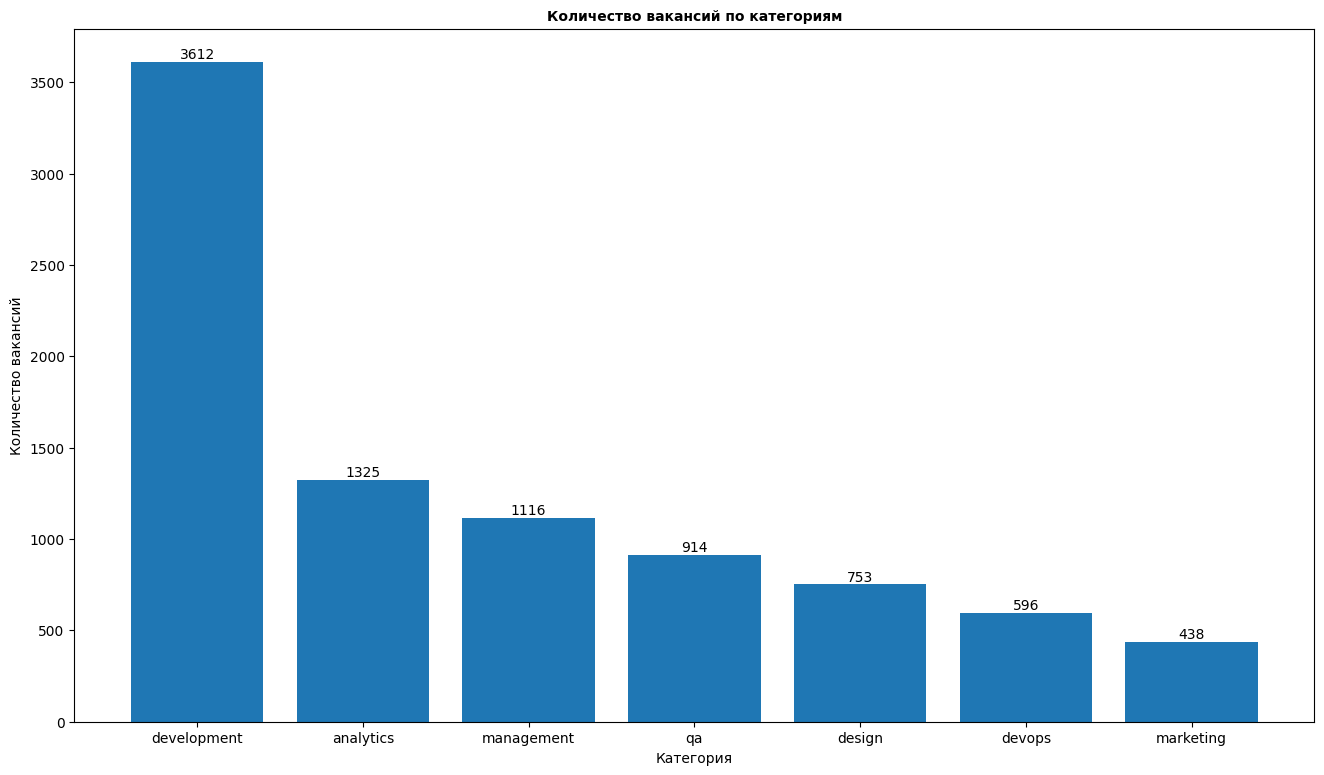

In [85]:
plt.figure(figsize=(16, 9))
categories = df["category"].value_counts()
x = categories.index
y = categories.values
plt.title("Количество вакансий по категориям", fontsize=10, fontweight="bold")
plt.xlabel("Категория")
plt.ylabel("Количество вакансий")
plt.bar_label(plt.bar(x, y))
plt.show()

Заметим, что в категории development больше всего вакансий, тогда посмотрим какие специалисты по грейдам требуются 

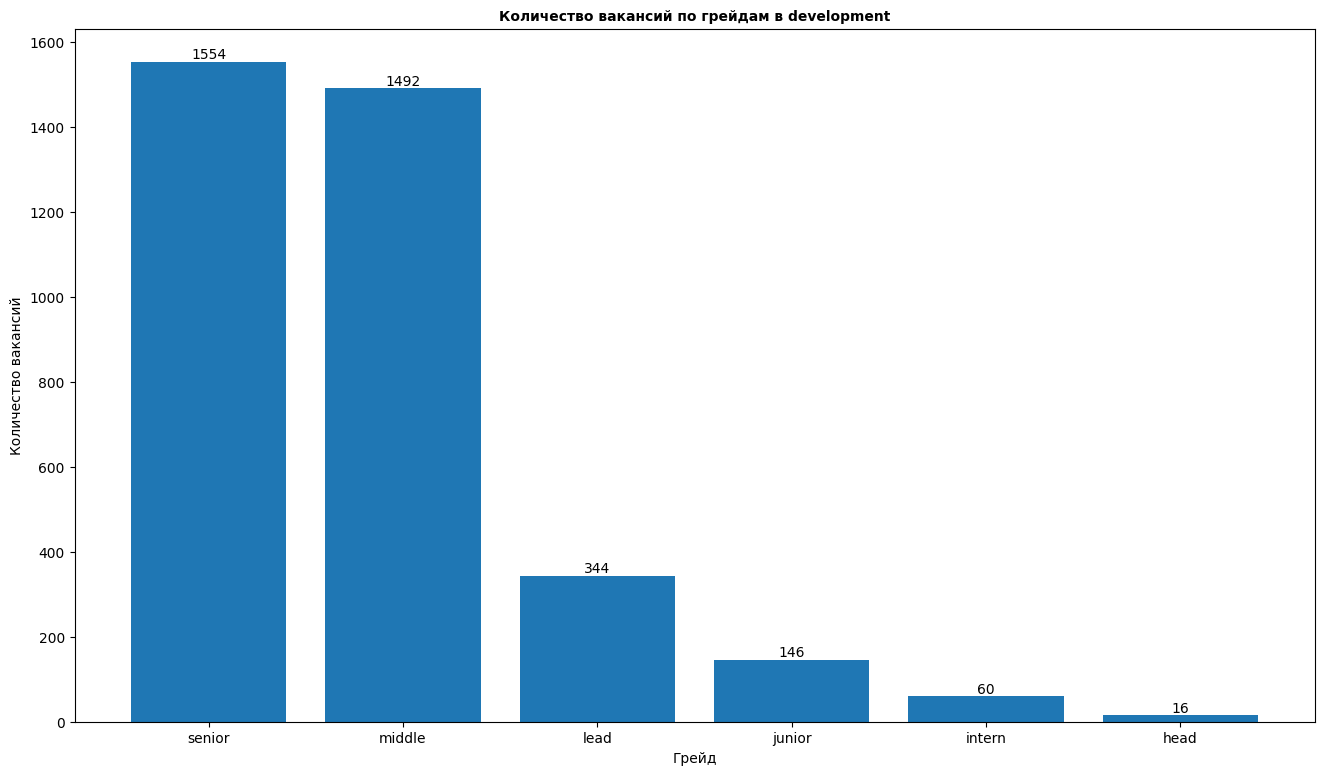

In [87]:
plt.figure(figsize=(16, 9))
devs = df[df["category"] == "development"]
devgrades = devs["level"].value_counts()
x = devgrades.index
y = devgrades.values
plt.title(
    "Количество вакансий по грейдам в development", fontsize=10, fontweight="bold"
)
plt.xlabel("Грейд")
plt.ylabel("Количество вакансий")
plt.bar_label(plt.bar(x, y))
plt.show()

Видим, что большинство работодателей ищут самостоятельных специалистов(senior, middle), поменьше ищут руководителей команд(lead), начинающих специалистов ищут еще меньше (в сумме 206) из 3612 вакансий, что может говорить о том, что в связщи ростом заинтересованности в it в России и в целом по всему миру, очень много специалистов без опыта, имеющих желание устроиться на работу, поэтому из-за огромного количества новичков порог входа повышается и работодатели не сильно хотоят выращивать специалиста из новичка. Грейд head имеет всего лишь 16 вакансий. 

Теперь можно посмотреть как меняются зарплаты в development в зависимости от грейда

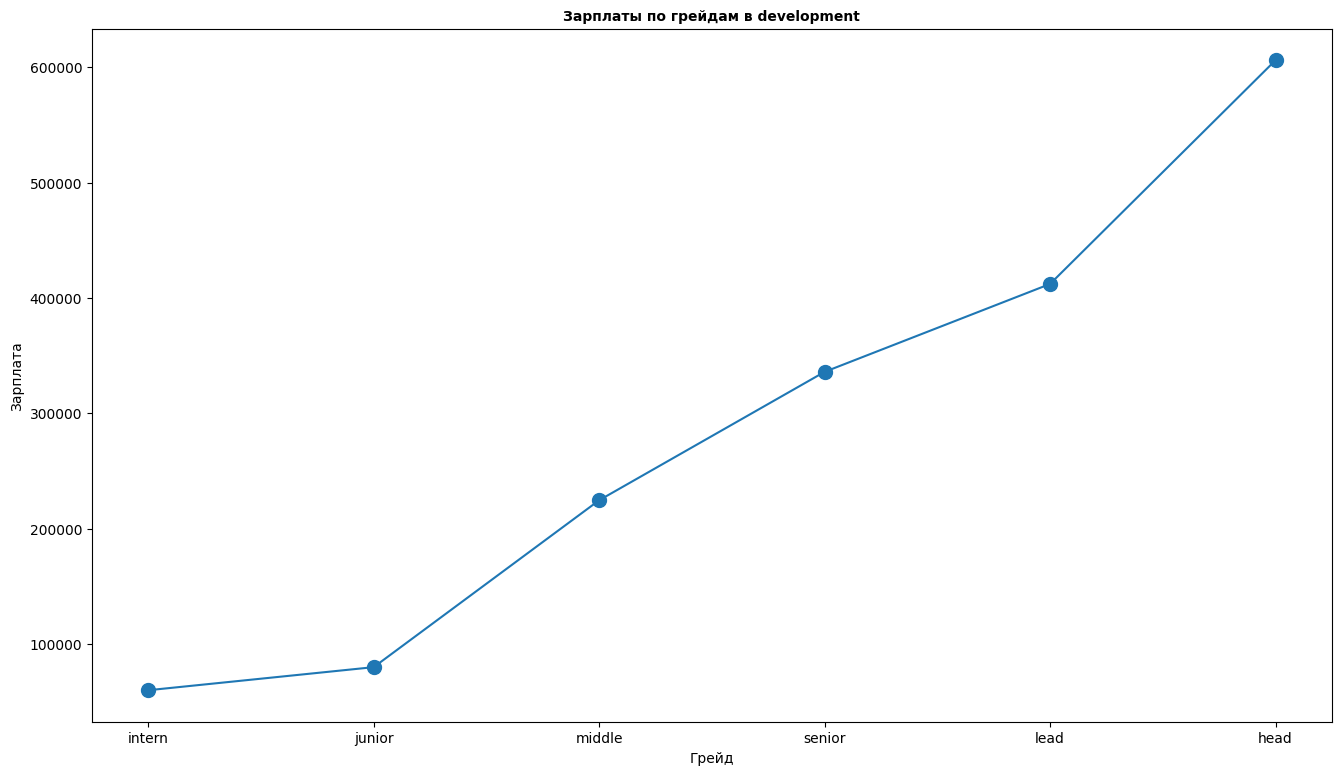

In [88]:
plt.figure(figsize=(16, 9))
devs = df[df["category"] == "development"]
devsalaries = devs.groupby("level")["salary"].median().sort_values()
x = devsalaries.index
y = devsalaries.values
plt.title("Зарплаты по грейдам в development", fontsize=10, fontweight="bold")
plt.xlabel("Грейд")
plt.ylabel("Зарплата")
plt.plot(x, y, marker="o", markersize="10")
plt.show()

В целом видим, что достаточно весомые скачки в зарплате происходят при переходе от начинающего специалиста к самостоятельному(middle) при переходе на руководящую должность, там зарплаты гораздо-гораздо выше.

Можно еще посмотреть какой формат сейчас опережает остальные по зарплатам

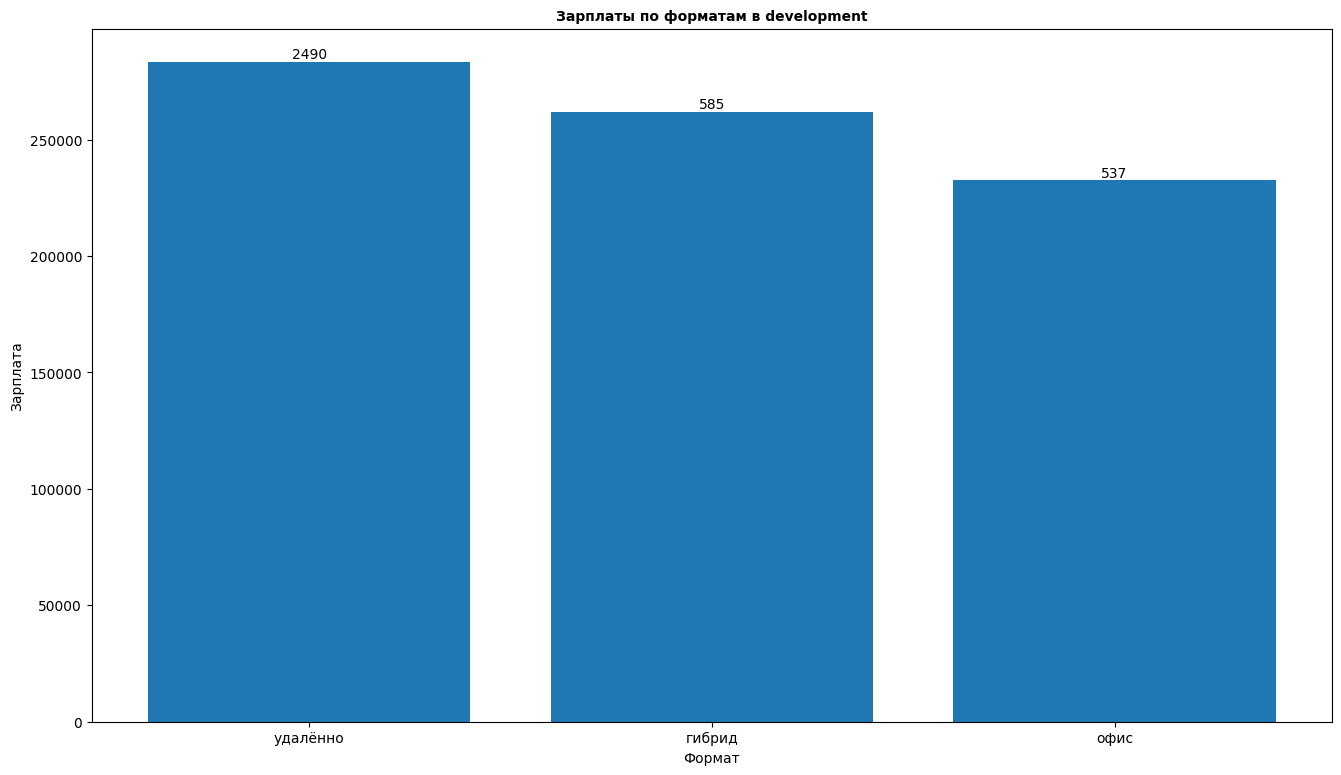

In [89]:
plt.figure(figsize=(16, 9))
devs = df[df["category"] == "development"]
counts = devs["format"].value_counts()
devsalaries = devs.groupby("format")["salary"].median().sort_values(ascending=False)
x = devsalaries.index
y = devsalaries.values
plt.title("Зарплаты по форматам в development", fontsize=10, fontweight="bold")
plt.xlabel("Формат")
plt.ylabel("Зарплата")
plt.bar_label(plt.bar(x, y), labels=counts.values)
plt.show()

Удаленных вакансий для разработчиков очень много, посмотрим теперь как распределены грейды.

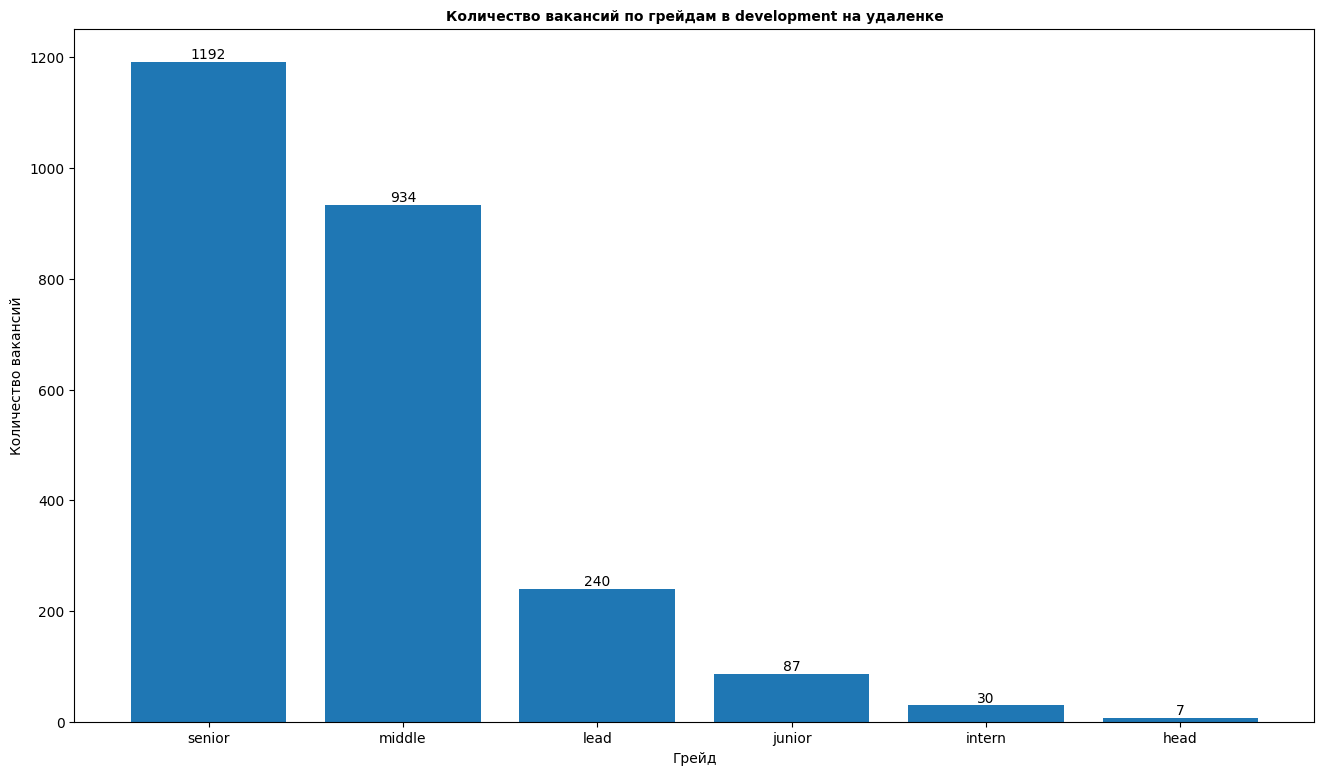

In [92]:
plt.figure(figsize=(16, 9))
devs = df[(df["category"] == "development") & (df["format"] == "удалённо")]
devgrades = devs["level"].value_counts()
x = devgrades.index
y = devgrades.values
plt.title(
    "Количество вакансий по грейдам в development на удаленке",
    fontsize=10,
    fontweight="bold",
)
plt.xlabel("Грейд")
plt.ylabel("Количество вакансий")
plt.bar_label(plt.bar(x, y))
plt.show()

Около 75% всех вакансий принадлежать senior'ам и middle'ам, что говорит о том, что удаленный рынок требует большой автономности от кандидатов. 

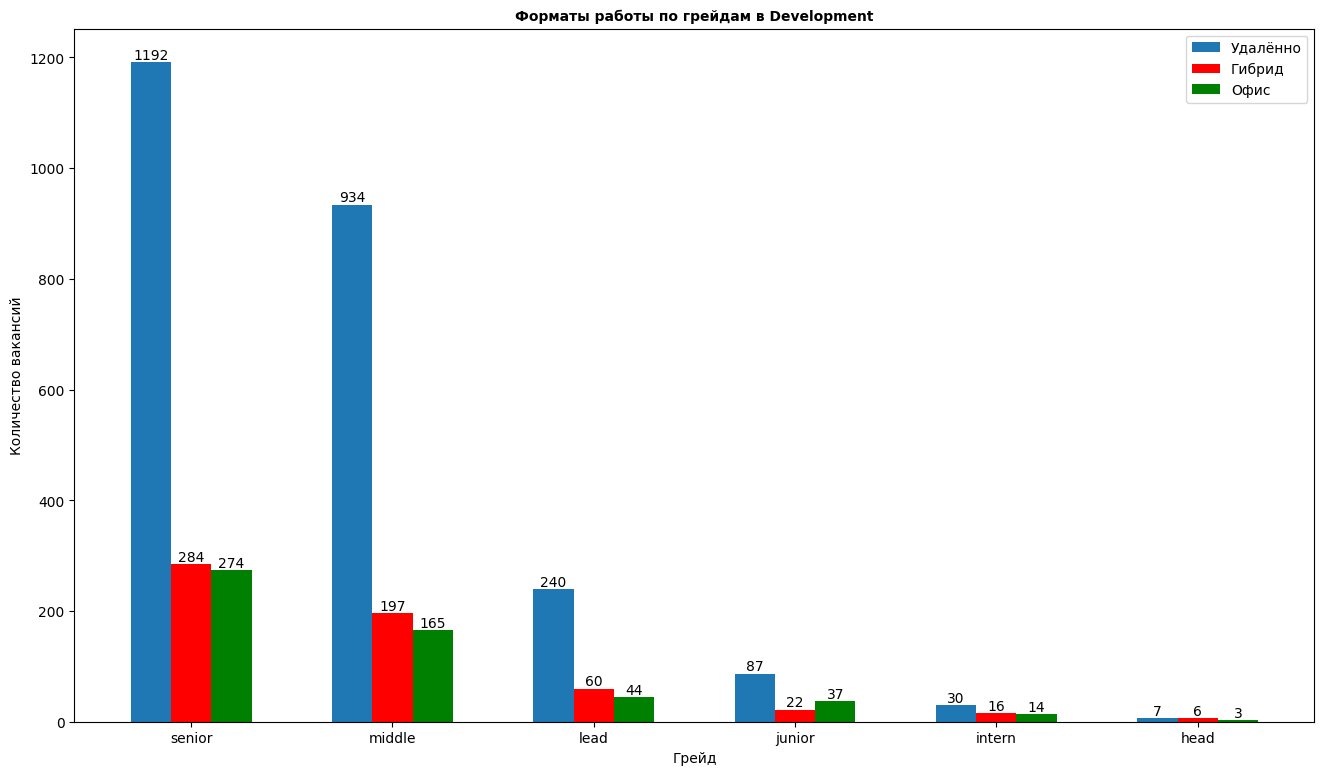

In [83]:
plt.figure(figsize=(16, 9))
devs = df[df["category"] == "development"]
y1 = devs[devs["format"] == "удалённо"]["level"].value_counts()
y2 = devs[devs["format"] == "гибрид"]["level"].value_counts()
y3 = devs[devs["format"] == "офис"]["level"].value_counts()
grades = devs["level"].unique()
x = np.arange(len(grades))
b1 = plt.bar(x - 0.2, y1, width=0.2, label="Удалённо")
b2 = plt.bar(x, y2, width=0.2, label="Гибрид", color="red")
b3 = plt.bar(x + 0.2, y3, width=0.2, label="Офис", color="green")
plt.bar_label(b1)
plt.bar_label(b2)
plt.bar_label(b3)
plt.xticks(x, grades)
plt.title("Форматы работы по грейдам в Development", fontsize=10, fontweight="bold")
plt.xlabel("Грейд")
plt.ylabel("Количество вакансий")
plt.legend()
plt.show()

В целом прослеживается тенденция на удаленный формат работы на всех грейдах.

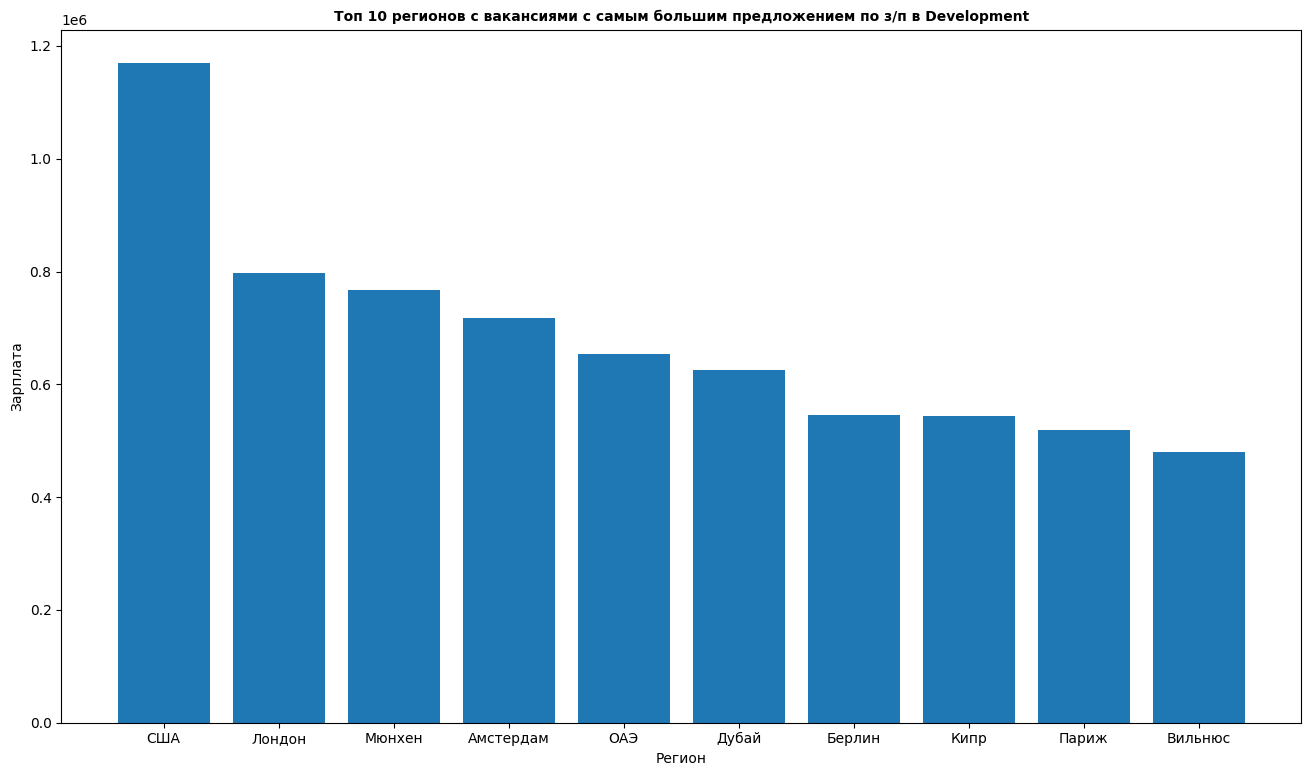

In [80]:
plt.figure(figsize=(16, 9))
devs = df[df["category"] == "development"]
counts = devs["city/country"].value_counts()
regions = (
    devs.groupby("city/country")["salary"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)
x = regions.index
y = regions.values
plt.title(
    "Топ 10 регионов с вакансиями с самым большим предложением по з/п в Development",
    fontsize=10,
    fontweight="bold",
)
plt.xlabel("Регион")
plt.ylabel("Зарплата")
plt.bar(x, y)
plt.show()

Вакансии с самыми большими зарплатами предлагают компании из Европы и США